In [1]:
from pathlib import Path
import importlib.util
import inspect
import sys

def load_module(module_name, filename_candidates):
    search_roots = [
        Path.cwd(),
        Path.cwd() / "python_version",
        Path.cwd().parent,
    ]
    for root in search_roots:
        for name in filename_candidates:
            path = root / name
            if path.exists():
                spec = importlib.util.spec_from_file_location(module_name, path)
                module = importlib.util.module_from_spec(spec)
                sys.modules[module_name] = module
                spec.loader.exec_module(module)
                print(f"Loaded {module_name} from: {path}")
                return module
    raise FileNotFoundError(f"Could not find any of: {filename_candidates}")

gillespie = load_module("gillespie", ["gillespie.py", "gillespie(7).py"])
prc1 = load_module("prc1", ["prc1.py", "prc1(7).py"])
prc1_state = load_module("prc1_state", ["prc1_state.py", "prc1_state(7).py"])
run_gillespie = load_module("run_gillespie", ["run_gillespie.py", "run_gillespie(6).py"])
smc_abc = load_module("smc_abc", ["smc_abc.py", "smc-abc.py", "smc-abc(6).py"])

sig = inspect.signature(run_gillespie.run_gillespie_prc1_on_grid)
required_flags = {
    "enable_initial_attach_cooperativity",
    "enable_second_head_attach_cooperativity",
    "enable_second_head_detach_cooperativity",
}
missing = sorted(required_flags - set(sig.parameters))
if missing:
    raise RuntimeError(
        "Your loaded run_gillespie module does not have the new cooperativity flags. "
        f"Missing: {missing}. Make sure you are loading the patched files."
    )

print("Patched cooperativity flags detected successfully.")

Loaded gillespie from: C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\gillespie.py
Loaded prc1 from: C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\prc1.py
Loaded prc1_state from: C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\prc1_state.py
Loaded run_gillespie from: C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\run_gillespie.py
Loaded smc_abc from: C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\smc_abc.py
Patched cooperativity flags detected successfully.


In [2]:
import numpy as np

# fixed model parameters
INIT_BIND = 0.002
K_DET_1 = 0.1
K12_FIXED = 5.88
MAX_STEPS = 50000

# observation grid
times_obs = np.arange(0.0, 68.0 + 4.0, 4.0)

# thermal scale and fixed cooperativity
k_B_T = 4.1
EPS_FIXED = 2.3 * k_B_T

# true k21 used for synthetic data
K21_TRUE = 0.1

print("times_obs =", times_obs)
print("EPS_FIXED =", EPS_FIXED)
print("K12_FIXED =", K12_FIXED)
print("K21_TRUE =", K21_TRUE)

times_obs = [ 0.  4.  8. 12. 16. 20. 24. 28. 32. 36. 40. 44. 48. 52. 56. 60. 64. 68.]
EPS_FIXED = 9.429999999999998
K12_FIXED = 5.88
K21_TRUE = 0.1


## Define the `k21` inference mapping for the general 4-parameter SMC file

The updated `smc_abc.py` expects the **full simulator parameter vector**

`theta_full = [R01, k10, k12, k21]`

but the notebook still infers only **one** parameter:

- `theta_raw[0] = k21 = base_double_detachment_rate`

So we define a transform from the 1-parameter inferred vector to the full 4-parameter simulator vector, and we pass the cooperativity / hopping settings through `sim_kwargs`.


In [3]:
sim_kwargs = dict(
    cooperativity_energy=EPS_FIXED,
    enable_initial_attach_cooperativity=False,
    enable_second_head_attach_cooperativity=True,
    enable_second_head_detach_cooperativity=True,
    enable_hopping=False,
    max_steps=MAX_STEPS,
)

def theta_transform_k21(theta_raw):
    """
    Map the inferred 1-parameter vector to the full 4-parameter simulator vector:
        theta_full = [R01, k10, k12, k21]
    """
    k21 = float(np.asarray(theta_raw, dtype=float)[0])
    return np.array([INIT_BIND, K_DET_1, K12_FIXED, k21], dtype=float)

def simulate_one_k21_detach_only(theta_raw, times_obs, seed):
    """
    Convenience wrapper for one-parameter k21 simulation using the general smc_abc.py file.
    theta_raw[0] = k21.
    """
    theta_full = theta_transform_k21(theta_raw)
    return smc_abc.simulate_one(theta_full, times_obs, seed, sim_kwargs=sim_kwargs)

print("theta_transform_k21 and sim_kwargs are ready.")
print("sim_kwargs =", sim_kwargs)


theta_transform_k21 and sim_kwargs are ready.
sim_kwargs = {'cooperativity_energy': 9.429999999999998, 'enable_initial_attach_cooperativity': False, 'enable_second_head_attach_cooperativity': True, 'enable_second_head_detach_cooperativity': True, 'enable_hopping': False, 'max_steps': 50000}


In [4]:
import time

theta_test = np.array([K21_TRUE], dtype=float)

t0 = time.perf_counter()
test_path = simulate_one_k21_detach_only(theta_test, times_obs, seed=123)
t1 = time.perf_counter()

one_sim_seconds = t1 - t0

print("One simulation path:")
print(test_path)
print("Shape:", test_path.shape)
print(f"Time for one simulation: {one_sim_seconds:.6f} seconds")

One simulation path:
[  0.  14.  21.  32.  40.  43.  52.  59.  63.  68.  77.  91. 101. 108.
 111. 114. 124. 125.]
Shape: (18,)
Time for one simulation: 25.898125 seconds


In [5]:
print("Using general 4-parameter smc_abc.py with a 1-parameter theta_transform.")
print("joblib available:", getattr(smc_abc, "_JOBLIB_AVAILABLE", None))
print("parallel backend to use in the SMC call: threads")


Using general 4-parameter smc_abc.py with a 1-parameter theta_transform.
joblib available: True
parallel backend to use in the SMC call: threads


In [6]:
n_obs_reps = 10

y_obs = np.array([
    simulate_one_k21_detach_only(np.array([K21_TRUE], dtype=float), times_obs, seed=i)
    for i in range(n_obs_reps)
], dtype=float)

print("y_obs shape:", y_obs.shape)
print("Observed summary dimension:", smc_abc.summarize_paths(y_obs).shape)


y_obs shape: (10, 18)
Observed summary dimension: (36,)


In [7]:
K21_center = 0.3   # intentionally inaccurate prior center
phi_mu = np.array([np.log(K21_center)], dtype=float)
phi_sd = np.array([0.5], dtype=float)

print("true k21 =", K21_TRUE)
print("prior center =", K21_center)
print("phi_mu =", phi_mu)
print("phi_sd =", phi_sd)

true k21 = 0.1
prior center = 0.3
phi_mu = [-1.2039728]
phi_sd = [0.5]


In [8]:
res = smc_abc.smc_abc_prc1(
    times_obs=times_obs,
    y_obs=y_obs,
    phi_mu=phi_mu,
    phi_sd=phi_sd,
    P=30,
    G=3,
    pool=60,
    n_reps=1,
    eps_quantile=50.0,
    cov_scale=2.0,
    seed=1,
    n_jobs=-1,
    batch_factor=16,
    theta_transform=theta_transform_k21,
    sim_kwargs=sim_kwargs,
    parallel_backend="threads",
)

print("Finished SMC-ABC.")
print("eps history:", res.eps_history)


[SMC-ABC] Starting pilot run
[SMC-ABC] Time: 2026-04-19 21:26:40
[SMC-ABC] Pilot finished in 1h 5m 12.0s
[SMC-ABC] Initial epsilon = 244.635

[SMC-ABC] Generation 2/3 started at 2026-04-19 22:31:52
[SMC-ABC] Target epsilon = 241.985
[SMC-ABC] Generation 2/3, batch 1: accepted so far 0/30, proposals seen 480
[SMC-ABC] Generation 2/3: accepted 25/30 after 480 proposals (acc rate 0.052), elapsed 7h 8m 3.2s, ETA for this generation: 2026-04-20 05:41:30
[SMC-ABC] Generation 2/3: accepted 30/30 after 480 proposals (acc rate 0.062), elapsed 7h 8m 3.2s, ETA for this generation: 2026-04-20 05:39:54
[SMC-ABC] Generation 2/3 finished in 7h 8m 3.2s
[SMC-ABC] Estimated overall finish time: 2026-04-20 12:47:58

[SMC-ABC] Generation 3/3 started at 2026-04-20 05:39:54
[SMC-ABC] Target epsilon = 240.551
[SMC-ABC] Generation 3/3, batch 1: accepted so far 0/30, proposals seen 480
[SMC-ABC] Generation 3/3: accepted 25/30 after 480 proposals (acc rate 0.052), elapsed 7h 8m 16.6s, ETA for this generation: 2

In [9]:
posterior_k21 = np.exp(res.particles_phi[:, 0])
posterior_w = res.weights

print("posterior k21 particles:")
print(posterior_k21)
print("posterior weights:")
print(posterior_w)

posterior k21 particles:
[0.18628263 0.11363132 0.19510138 0.17798469 0.22463219 0.24097508
 0.09312291 0.06586296 0.09111738 0.13580932 0.20821162 0.17580802
 0.14185103 0.20014711 0.20821729 0.11859854 0.16374699 0.06205425
 0.12940622 0.09480538 0.23034732 0.28545942 0.06739323 0.13068281
 0.13774915 0.20313751 0.1754662  0.21554569 0.0569491  0.09896146]
posterior weights:
[0.04291588 0.01867408 0.04619316 0.03990006 0.05770247 0.0644134
 0.01269221 0.0056602  0.01213136 0.02557124 0.0512021  0.03911986
 0.02752424 0.04810167 0.0512043  0.02018191 0.03487831 0.0048247
 0.0235363  0.01316649 0.06002253 0.08378089 0.00600954 0.02393917
 0.02619479 0.04924417 0.03899775 0.05407468 0.00379068 0.01435185]


In [10]:
post_mean = np.sum(posterior_w * posterior_k21)

order = np.argsort(posterior_k21)
k21_sorted = posterior_k21[order]
w_sorted = posterior_w[order]
cdf = np.cumsum(w_sorted)
post_median = k21_sorted[np.searchsorted(cdf, 0.5)]

print("True k21:", K21_TRUE)
print("Posterior mean:", post_mean)
print("Posterior median:", post_median)

True k21: 0.1
Posterior mean: 0.19029882930432362
Posterior median: 0.20014711059756327


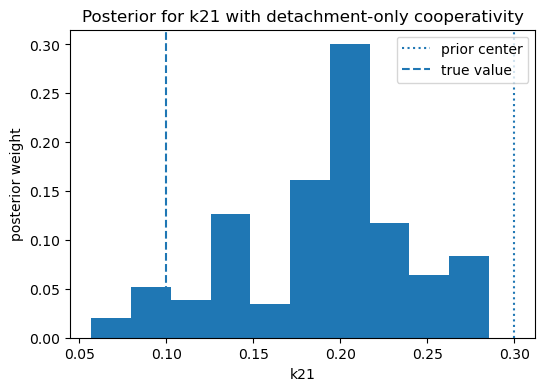

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.hist(posterior_k21, bins=10, weights=posterior_w)
plt.axvline(K21_center, linestyle=":", label="prior center")
plt.axvline(K21_TRUE, linestyle="--", label="true value")
plt.xlabel("k21")
plt.ylabel("posterior weight")
plt.title("Posterior for k21 with detachment-only cooperativity")
plt.legend()
plt.show()

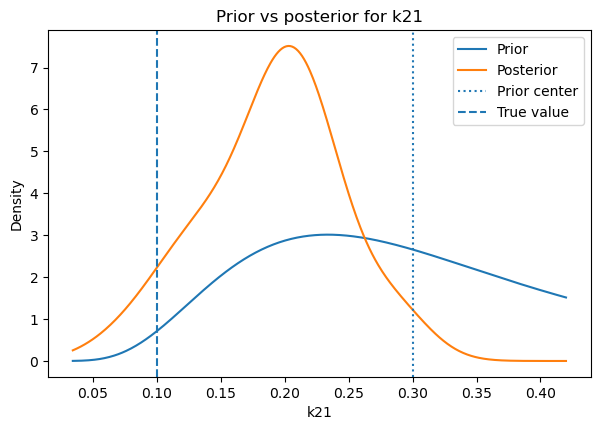

In [12]:
from scipy.stats import gaussian_kde

posterior_samples = np.asarray(posterior_k21, dtype=float)
posterior_w = np.asarray(posterior_w, dtype=float)

phi0 = float(phi_mu[0])
sd0 = float(phi_sd[0])

def prior_density(x):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    mask = x > 0
    z = (np.log(x[mask]) - phi0) / sd0
    out[mask] = np.exp(-0.5 * z * z) / (x[mask] * sd0 * np.sqrt(2 * np.pi))
    return out

kde_post = gaussian_kde(posterior_samples, weights=posterior_w)

xmin = min(np.min(posterior_samples), K21_TRUE, K21_center) * 0.6
xmax = max(np.max(posterior_samples), K21_TRUE, K21_center) * 1.4
xmin = max(xmin, 1e-8)

xgrid = np.linspace(xmin, xmax, 500)

prior_y = prior_density(xgrid)
post_y = kde_post(xgrid)

plt.figure(figsize=(7, 4.5))
plt.plot(xgrid, prior_y, label="Prior")
plt.plot(xgrid, post_y, label="Posterior")
plt.axvline(K21_center, linestyle=":", label="Prior center")
plt.axvline(K21_TRUE, linestyle="--", label="True value")
plt.xlabel("k21")
plt.ylabel("Density")
plt.title("Prior vs posterior for k21")
plt.legend()
plt.show()